# Проект: прогнозирование стоимости объектов недвижимости

## Бизнес-задача

Агентство недвижимости хочет сократить время, которое риелторы
затрачивают на анализ объявлений и определение справедливой стоимости
объектов недвижимости.

Цель проекта — разработать ML-модель, способную на основе характеристик
объекта недвижимости прогнозировать его рыночную стоимость.

Полученная модель может использоваться для:

- автоматической предварительной оценки объекта;
- выявления потенциально недооценённых предложений;
- ускорения обработки новых объявлений;
- ранжирования объектов по потенциальной привлекательности.

In [136]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

import pickle

In [137]:
DATA_PATH = r'C:\DS\SF\Final project 26\data.csv'

data = pd.read_csv(DATA_PATH)

data.head()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', 'PK–2', '6–8', '9–12', 'PK–5', 'K–12']}, 'name': ['Southern Pines Elementary School', 'Southern Middle School', 'Pinecrest High School', 'Southern Pines Primary School', ""Crain's Creek Middle School"", 'Union Pines High School', 'Episcopal Day Private School', 'Calvary Christian Private School']}]",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '5828 sqft', 'factLabel': 'lotsize'}, {'factValue': '$159/sqft', 'factLabel': 'Price/sqft'}]}",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1.65mi', '1.32mi', '1.01mi'], 'Grades': ['9-12', '3-8', 'PK-8']}, 'name': ['East Valley High School&Extension', 'Eastvalley Middle School', 'Trentwood Elementary School']}]","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'factLabel': 'Year built'}, {'factValue': '1967', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central', 'factLabel': 'Cooling'}, {'factValue': 'Attached Garage', 'factLabel': 'Parking'}, {'factValue': '8,626 sqft', 'factLabel': 'lotsize'}, {'factValue': '$965/sqft', 'factLabel': 'Price/sqft'}]}",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': {'Distance': ['1.19mi', '2.06mi', '2.63mi'], 'Grades': ['6-8', 'K-5', '9-12']}, 'name': ['Paul Revere Middle School', 'Brentwood Science School', 'Palisades Charter High School']}]","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'factLabel': 'Year built'}, {'factValue': '2006', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central', 'factLabel': 'Cooling'}, {'factValue': 'Detached Garage', 'factLabel': 'Parking'}, {'factValue': '8,220 sqft', 'factLabel': 'lotsize'}, {'factValue': '$371/sqft', 'factLabel': 'Price/sqft'}]}",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'], 'data': {'Distance': ['1.05mi', '0.1mi', '1.05mi', '0.81mi'], 'Grades': ['5-6', 'PK-4', '7-8', '9-12']}, 'name': ['Mcculloch Intermediate School', 'Bradfield Elementary School', 'Highland Park Middle School', 'Highland Park High School']}]","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '10,019 sqft', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': {'Distance': ['5.96mi', '3.25mi', '3.03mi'], 'Grades': ['7-8', '9-12', 'PK-6']}, 'name': [

In [138]:
print('Размер датасета:', data.shape)

Размер датасета: (377185, 18)


In [139]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103114 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226469 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

In [140]:
print(data.columns.tolist())

['status', 'private pool', 'propertyType', 'street', 'baths', 'homeFacts', 'fireplace', 'city', 'schools', 'sqft', 'zipcode', 'beds', 'state', 'stories', 'mls-id', 'PrivatePool', 'MlsId', 'target']


In [141]:
print('SHAPE:')
print(data.shape)

print('\nCOLUMNS:')
print(data.columns.tolist())

print('\nDTYPES:')
print(data.dtypes)

print('\nMISSING VALUES:')
print(data.isna().sum().sort_values(ascending=False))

print('\nHEAD:')
display(data.head())

SHAPE:
(377185, 18)

COLUMNS:
['status', 'private pool', 'propertyType', 'street', 'baths', 'homeFacts', 'fireplace', 'city', 'schools', 'sqft', 'zipcode', 'beds', 'state', 'stories', 'mls-id', 'PrivatePool', 'MlsId', 'target']

DTYPES:
status          object
private pool    object
propertyType    object
street          object
baths           object
homeFacts       object
fireplace       object
city            object
schools         object
sqft            object
zipcode         object
beds            object
state           object
stories         object
mls-id          object
PrivatePool     object
MlsId           object
target          object
dtype: object

MISSING VALUES:
private pool    373004
mls-id          352243
PrivatePool     336874
fireplace       274071
stories         150716
baths           106338
beds             91282
MlsId            66880
sqft             40577
status           39918
propertyType     34733
target            2481
city                34
street             

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', 'PK–2', '6–8', '9–12', 'PK–5', 'K–12']}, 'name': ['Southern Pines Elementary School', 'Southern Middle School', 'Pinecrest High School', 'Southern Pines Primary School', ""Crain's Creek Middle School"", 'Union Pines High School', 'Episcopal Day Private School', 'Calvary Christian Private School']}]",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '5828 sqft', 'factLabel': 'lotsize'}, {'factValue': '$159/sqft', 'factLabel': 'Price/sqft'}]}",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1.65mi', '1.32mi', '1.01mi'], 'Grades': ['9-12', '3-8', 'PK-8']}, 'name': ['East Valley High School&Extension', 'Eastvalley Middle School', 'Trentwood Elementary School']}]","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'factLabel': 'Year built'}, {'factValue': '1967', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central', 'factLabel': 'Cooling'}, {'factValue': 'Attached Garage', 'factLabel': 'Parking'}, {'factValue': '8,626 sqft', 'factLabel': 'lotsize'}, {'factValue': '$965/sqft', 'factLabel': 'Price/sqft'}]}",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': {'Distance': ['1.19mi', '2.06mi', '2.63mi'], 'Grades': ['6-8', 'K-5', '9-12']}, 'name': ['Paul Revere Middle School', 'Brentwood Science School', 'Palisades Charter High School']}]","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'factLabel': 'Year built'}, {'factValue': '2006', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central', 'factLabel': 'Cooling'}, {'factValue': 'Detached Garage', 'factLabel': 'Parking'}, {'factValue': '8,220 sqft', 'factLabel': 'lotsize'}, {'factValue': '$371/sqft', 'factLabel': 'Price/sqft'}]}",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'], 'data': {'Distance': ['1.05mi', '0.1mi', '1.05mi', '0.81mi'], 'Grades': ['5-6', 'PK-4', '7-8', '9-12']}, 'name': ['Mcculloch Intermediate School', 'Bradfield Elementary School', 'Highland Park Middle School', 'Highland Park High School']}]","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '10,019 sqft', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': {'Distance': ['5.96mi', '3.25mi', '3.03mi'], 'Grades': ['7-8', '9-12', 'PK-6']}, 'name': [

## 1. Постановка задачи

# Проект: прогнозирование стоимости объектов недвижимости

## Бизнес-задача

Агентство недвижимости хочет сократить время, которое риелторы
затрачивают на анализ объявлений и определение справедливой стоимости
объектов недвижимости.

Цель проекта — разработать ML-модель, способную на основе характеристик
объекта недвижимости прогнозировать его рыночную стоимость.

Полученная модель может использоваться для:

- автоматической предварительной оценки объекта;
- выявления потенциально недооценённых предложений;
- ускорения обработки новых объявлений;
- ранжирования объектов по потенциальной привлекательности.

## 2. EDA и очистка

Здесь мы исследуем:

In [142]:
data.describe().T

,count,unique,top,freq
status,337267,159,for sale,156104
private pool,4181,1,Yes,4181
propertyType,342452,1280,single-family home,92206
street,377183,337076,Address Not Disclosed,672
baths,270847,229,2 Baths,52466
homeFacts,377185,321009,"{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '—', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}",7174
fireplace,103114,1652,yes,50356
city,377151,2026,Houston,24442
schools,377185,297365,"[{'rating': [], 'data': {'Distance': [], 'Grades': []}, 'name': []}]",4204
sqft,336608,25405,0,11854


Категориальные:

In [143]:
data.describe(include='object').T

,count,unique,top,freq
status,337267,159,for sale,156104
private pool,4181,1,Yes,4181
propertyType,342452,1280,single-family home,92206
street,377183,337076,Address Not Disclosed,672
baths,270847,229,2 Baths,52466
homeFacts,377185,321009,"{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '—', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}",7174
fireplace,103114,1652,yes,50356
city,377151,2026,Houston,24442
schools,377185,297365,"[{'rating': [], 'data': {'Distance': [], 'Grades': []}, 'name': []}]",4204
sqft,336608,25405,0,11854


Пропуски:

In [144]:
missing = (
    data.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(missing[missing > 0])

private pool    98.891525
mls-id          93.387330
PrivatePool     89.312672
fireplace       72.662221
stories         39.958111
baths           28.192532
beds            24.200856
MlsId           17.731352
sqft            10.757851
status          10.583136
propertyType     9.208479
target           0.657767
city             0.009014
street           0.000530
dtype: float64

Дубликаты:

In [145]:
print('Количество полных дубликатов:', data.duplicated().sum())

Количество полных дубликатов: 50


Если они действительно дубликаты объявлений:

In [146]:
data = data.drop_duplicates().copy()

## 3. Target — цена недвижимости



### Исследование целевой переменной — стоимости недвижимости

Целевой переменной в данной задаче является признак `target`, содержащий стоимость объекта недвижимости.

Первичный анализ показал, что `target` имеет тип `object`. Для решения задачи регрессии необходимо преобразовать целевую переменную в числовой формат.

Перед преобразованием исследуем исходные значения, очистим их от символов валюты, разделителей и других нечисловых символов, после чего проанализируем распределение стоимости недвижимости и наличие потенциальных выбросов.

3.1. Посмотрим исходный target

In [147]:
TARGET_RAW = 'target'

print('Тип target:', data[TARGET_RAW].dtype)
print('Пропусков:', data[TARGET_RAW].isna().sum())
print('Уникальных значений:', data[TARGET_RAW].nunique())

display(data[[TARGET_RAW]].head(20))

Тип target: object
Пропусков: 2480
Уникальных значений: 43939


,target
0,"$418,000"
1,"$310,000"
2,"$2,895,000"
3,"$2,395,000"
4,"$5,000"
5,"$209,000"
6,"181,500"
7,"68,000"
8,"$244,900"
9,"$311,995"


3.2. Очищаем цену

In [148]:
import numpy as np
import pandas as pd

data['target_clean'] = (
    data['target']
    .astype('string')
    .str.replace(r'[^0-9.]', '', regex=True)
    .replace('', pd.NA)
)

data['target_clean'] = pd.to_numeric(
    data['target_clean'],
    errors='coerce'
)

TARGET = 'target_clean'

In [150]:
print('Тип после очистки:', data[TARGET].dtype)

print(
    'Пропусков после очистки:',
    data[TARGET].isna().sum()
)

display(
    data[['target', TARGET]].head(20)
)

Тип после очистки: Int64
Пропусков после очистки: 2480


,target,target_clean
0,"$418,000",418000
1,"$310,000",310000
2,"$2,895,000",2895000
3,"$2,395,000",2395000
4,"$5,000",5000
5,"$209,000",209000
6,"181,500",181500
7,"68,000",68000
8,"$244,900",244900
9,"$311,995",311995


3.3. Проверяем качество преобразования

Нам нужно убедиться, что очистка не создала странные цены:

In [151]:
display(
    data[TARGET].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

count          374655.0
mean      644759.595868
std      1841482.093804
min                 1.0
1%               6900.0
5%              36000.0
25%            186990.0
50%            320000.0
75%            582000.0
95%           1950000.0
99%           5995000.0
max         195000000.0
Name: target_clean, dtype: Float64

In [152]:
print('Минимальная цена:', data[TARGET].min())
print('Максимальная цена:', data[TARGET].max())

print(
    'Количество цен <= 0:',
    (data[TARGET] <= 0).sum()
)

Минимальная цена: 1
Максимальная цена: 195000000
Количество цен <= 0: 0


3.4. Удаляем строки, где target отсутствует

Поскольку без известной цены объект нельзя использовать для supervised-обучения:

In [153]:
data = data[
    data[TARGET].notna() &
    (data[TARGET] > 0)
].copy()

print(
    'Размер датасета после очистки target:',
    data.shape
)

Размер датасета после очистки target: (374655, 19)


3.5. Строим распределение стоимости

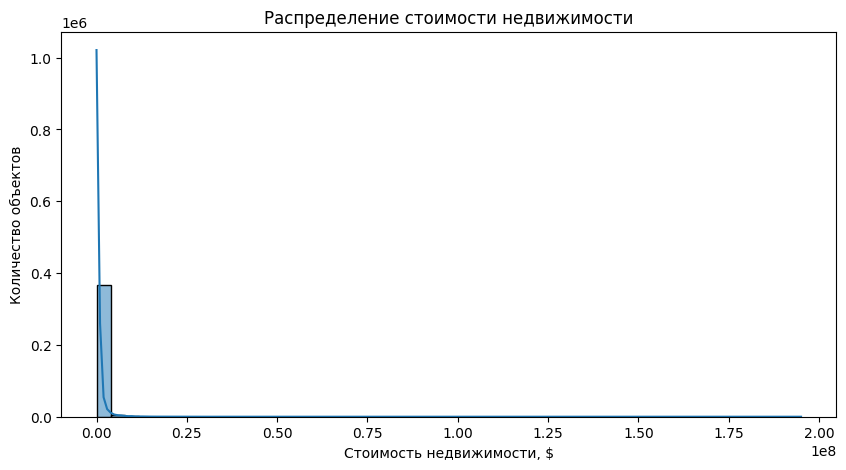

In [154]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x=TARGET,
    bins=50,
    kde=True
)

plt.title('Распределение стоимости недвижимости')
plt.xlabel('Стоимость недвижимости, $')
plt.ylabel('Количество объектов')
plt.show()

3.6. Boxplot

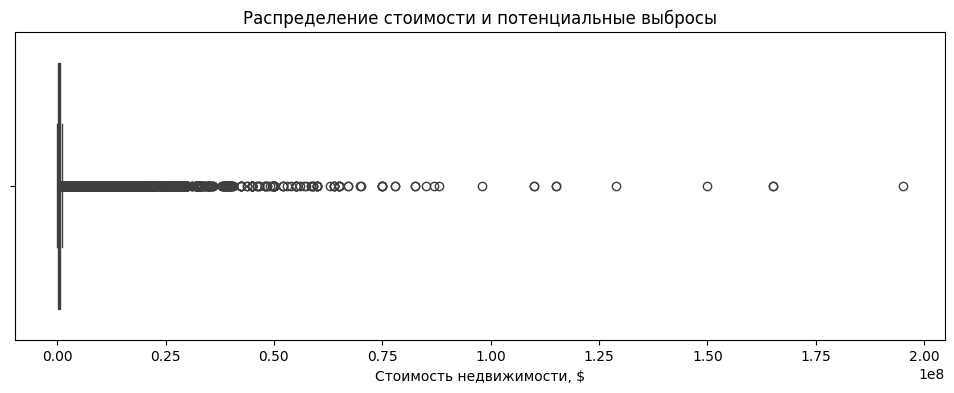

In [155]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=data,
    x=TARGET
)

plt.title('Распределение стоимости и потенциальные выбросы')
plt.xlabel('Стоимость недвижимости, $')
plt.show()

3.7. Логарифмированная цена

Для недвижимости это особенно важно, потому что распределение цены часто имеет длинный правый хвост.

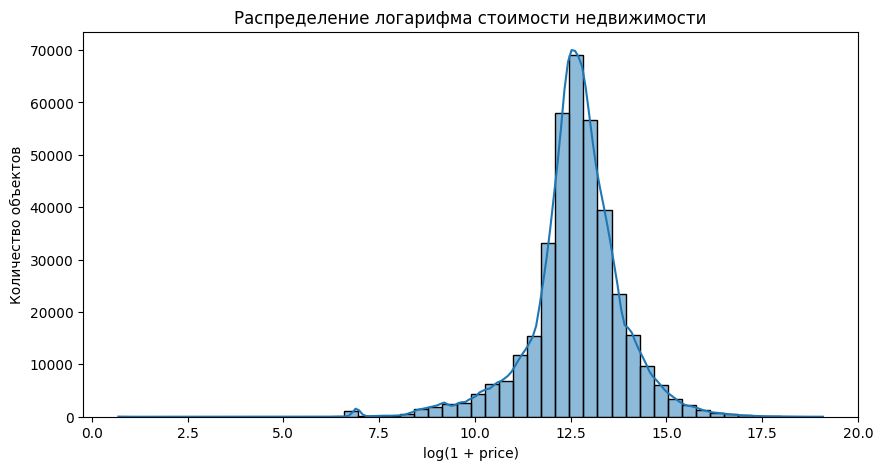

In [156]:
data['log_target'] = np.log1p(data[TARGET])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x='log_target',
    bins=50,
    kde=True
)

plt.title('Распределение логарифма стоимости недвижимости')
plt.xlabel('log(1 + price)')
plt.ylabel('Количество объектов')
plt.show()

### Вывод по исследованию целевой переменной

Исходное распределение стоимости недвижимости имеет выраженную правостороннюю асимметрию. Основная масса объектов сосредоточена в относительно небольшом диапазоне цен, при этом присутствует длинный правый хвост и ряд объектов с очень высокой стоимостью.

Boxplot также показывает большое количество потенциальных выбросов. Однако автоматически удалять такие наблюдения нельзя, поскольку высокая стоимость объекта недвижимости может быть обусловлена его реальными характеристиками и местоположением.

После логарифмического преобразования `log(1 + price)` распределение целевой переменной стало существенно более симметричным и приблизилось к нормальному. Это позволяет рассматривать логарифм стоимости в качестве целевой переменной для части моделей машинного обучения.

Перед моделированием необходимо дополнительно исследовать экстремально низкие и высокие значения стоимости и отделить реальные дорогие объекты от ошибок в данных.

In [157]:
# Основные статистики target
display(
    data[TARGET].describe(
        percentiles=[
            0.001,
            0.005,
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    )
)

print('\n10 самых дешёвых объектов:')
display(
    data[
        ['target', TARGET, 'propertyType', 'city',
         'state', 'sqft', 'beds', 'baths']
    ]
    .sort_values(TARGET)
    .head(10)
)

print('\n10 самых дорогих объектов:')
display(
    data[
        ['target', TARGET, 'propertyType', 'city',
         'state', 'sqft', 'beds', 'baths']
    ]
    .sort_values(TARGET, ascending=False)
    .head(10)
)

count          374655.0
mean      644759.595868
std      1841482.093804
min                 1.0
0.1%             1000.0
0.5%             4000.0
1%               6900.0
5%              36000.0
50%            320000.0
95%           1950000.0
99%           5995000.0
99.5%         9450000.0
99.9%        23990000.0
max         195000000.0
Name: target_clean, dtype: Float64


10 самых дешёвых объектов:


,target,target_clean,propertyType,city,state,sqft,beds,baths
320807,$1,1,Land,Amanda,OH,0,NaN,NaN
271049,$1,1,Land,Pataskala,OH,0,NaN,NaN
15533,$1,1,Single Family Home,Goodlettsville,TN,1596,3.0,2
289162,$1,1,single-family home,Goodlettsville,TN,"1,596 sqft",3 Beds,2 Baths
252299,$1,1,lot/land,Murfreesboro,TN,NaN,NaN,NaN
25334,$1,1,Single Family,Indianapolis,IN,"1,586",3,1.0
148240,$1,1,Land,Huntley,IL,0,NaN,NaN
304045,$1,1,single-family home,Indianapolis,IN,"1,586 sqft",3 Beds,NaN
256189,$1,1,Condo,Indianapolis,IN,"1,780",3,3.0
205356,$1,1,Land,Huntley,IL,0,NaN,NaN



10 самых дорогих объектов:


,target,target_clean,propertyType,city,state,sqft,beds,baths
132425,"$195,000,000",195000000,Single Family,Los Angeles,CA,--,11,18.0
143528,"$165,000,000",165000000,single-family home,Beverly Hills,CA,"28,660 sqft",20 Beds,23 Baths
285993,"$165,000,000",165000000,Single Family,Beverly Hills,CA,"28,660",20,23.0
110083,"$150,000,000",150000000,single-family home,Los Angeles,CA,NaN,NaN,NaN
178931,"$129,000,000",129000000,Single Family,Beverly Hills,CA,"43,000",12,23.0
119862,"$115,000,000",115000000,Single Family,Los Angeles,CA,"12,201",9,10.0
294206,"$115,000,000",115000000,single-family home,Los Angeles,CA,"12,201 sqft",9 Beds,10 Baths
354264,"$110,000,000",110000000,lot/land,Beverly Hills,CA,741 sqft,NaN,NaN
54164,"$110,000,000",110000000,single-family home,Beverly Hills,CA,"38,000 sqft",12 Beds,24 Baths
151594,"$98,000,000",98000000,Condo,New York,NY,"19,815",11,14


### 3.8. Очистка аномальных значений target

Для начала посмотрим диапазоны:

In [158]:
price_ranges = pd.cut(
    data[TARGET],
    bins=[
        0,
        1000,
        5000,
        10000,
        20000,
        50000,
        100000,
        np.inf
    ]
)

print(price_ranges.value_counts().sort_index())

target_clean
(0.0, 1000.0]            1069
(1000.0, 5000.0]         1563
(5000.0, 10000.0]        3936
(10000.0, 20000.0]       4925
(20000.0, 50000.0]      13860
(50000.0, 100000.0]     21246
(100000.0, inf]        328056
Name: count, dtype: int64


И отдельно исследуем объекты дешевле $10,000:

In [159]:
cheap = data[data[TARGET] < 10000]

print('Количество объектов дешевле $10,000:', len(cheap))
print(
    'Доля от датасета:',
    round(len(cheap) / len(data) * 100, 2),
    '%'
)

display(
    cheap['propertyType']
    .value_counts()
    .head(20)
)

Количество объектов дешевле $10,000: 6028
Доля от датасета: 1.61 %


propertyType
lot/land                         1967
Land                             1516
single-family home               1188
multi-family                      147
Single Family                     125
townhouse                          46
Multi Family                       31
Apartment                          29
Condo                              23
Single Family Home                 20
mobile/manufactured                18
Mobile / Manufactured              12
Multi-Family Home                  10
SingleFamilyResidence               8
Townhouse                           7
Condo/Townhome/Row Home/Co-Op       3
condo                               3
Bungalow                            2
Colonial                            2
Bi-Level                            1
Name: count, dtype: int64

Cледующим шагом проверяем дубликаты

Сначала полные:

In [160]:
print(
    'Полных дубликатов:',
    data.duplicated().sum()
)

Полных дубликатов: 0


Затем по адресу:

In [161]:
print(
    'Повторяющихся street:',
    data.duplicated(
        subset=['street', 'city', 'state'],
        keep=False
    ).sum()
)

Повторяющихся street: 72109


Посмотрим примеры:

In [162]:
address_duplicates = (
    data[
        data.duplicated(
            subset=['street', 'city', 'state'],
            keep=False
        )
    ]
    .sort_values(['state', 'city', 'street'])
)

display(
    address_duplicates[
        [
            'street',
            'city',
            'state',
            'target',
            'propertyType',
            'sqft',
            'beds',
            'baths',
            'MlsId',
            'mls-id'
        ]
    ].head(50)
)

,street,city,state,target,propertyType,sqft,beds,baths,MlsId,mls-id
5196,401 N. 109th Drive,Avondale,AZ,"$255,990",Single Family Home,"1,781",3,2.5,161719251,NaN
27413,401 N. 109th Drive,Avondale,AZ,"$297,490",Single Family Home,"2,158",3,2,161719260,NaN
72072,401 N. 109th Drive,Avondale,AZ,"$281,990",Single Family Home,"2,022",3,2.5,161719256,NaN
163311,401 N. 109th Drive,Avondale,AZ,"$292,990",Single Family Home,"2,472",4,2.5,161719259,NaN
249266,401 N. 109th Drive,Avondale,AZ,"$234,990",Single Family Home,"1,460",3,2.5,161719249,NaN
283739,401 N. 109th Drive,Avondale,AZ,"$261,990",Single Family Home,"1,589",2,2,161719254,NaN
284822,401 N. 109th Drive,Avondale,AZ,"$261,990",Single Family Home,"1,935",3,2.5,161719253,NaN
313716,401 N. 109th Drive,Avondale,AZ,"$310,990",Single Family Home,"2,355",4,3,161719261,NaN
314134,401 N. 109th Drive,Avondale,AZ,"$248,990",Single Family Home,"1,739",3,2.5,161719250,NaN
357698,401 N. 109th Drive,Avondale,AZ,"$258,990",Single Family Home,"1,904",3,2.5,161719252,NaN


И главное:

In [163]:
print('Всего строк:', len(data))

print(
    'Уникальных адресов:',
    data[
        ['street', 'city', 'state']
    ].drop_duplicates().shape[0]
)

Всего строк: 374655
Уникальных адресов: 335962


3.9. Проверяем подозрительно низкие цены

In [165]:
cheap = data[data[TARGET] <= 10000].copy()

print('Объектов <= $10,000:', len(cheap))
print(
    'Доля:',
    round(len(cheap) / len(data) * 100, 2),
    '%'
)

print('\nРаспределение цен:')
display(
    cheap[TARGET]
    .value_counts()
    .sort_index()
    .head(30)
)

print('\nСтатистика:')
display(cheap[TARGET].describe())

Объектов <= $10,000: 6568
Доля: 1.75 %

Распределение цен:


target_clean
1        15
3         2
8         1
20        1
25        1
29        1
30        1
250       1
393       1
400       1
500       4
600      32
700       5
750       9
800       8
825       3
850       2
875       2
890       1
900       3
925       1
950       4
975       1
990       1
1000    968
1050      1
1070      1
1075      1
1080      1
1095      2
Name: count, dtype: Int64


Статистика:


count         6568.0
mean     5825.745737
std      3070.316361
min              1.0
25%           3500.0
50%           6000.0
75%           8500.0
max          10000.0
Name: target_clean, dtype: Float64

In [166]:
display(
    cheap[
        [
            'target',
            'propertyType',
            'street',
            'city',
            'state',
            'sqft',
            'beds',
            'baths',
            'status'
        ]
    ].sample(
        min(30, len(cheap)),
        random_state=42
    )
)

,target,propertyType,street,city,state,sqft,beds,baths,status
145184,"1,000",NaN,676 NW 32nd St,Miami,FL,NaN,NaN,NaN,Active
301601,"$5,100",Land,14348 Stanfield Ave,Port Charlotte,FL,0,NaN,0,Active
260582,"$1,000",single-family home,8267 E Hollywood St,Detroit,MI,"1,476 sqft",3 Beds,NaN,foreclosure
162527,"$7,500",lot/land,844 Glencoe St E,Lehigh Acres,FL,NaN,NaN,NaN,for sale
110895,"$4,100",lot/land,1077 Ainsworth St E,Lehigh Acres,FL,NaN,NaN,NaN,for sale
362078,"$1,000",single-family home,20554 Joann St,Detroit,MI,721 sqft,2 Beds,NaN,foreclosure
106367,"$6,000",Land,SE 41 Ter Lot 38-43,Belleview,FL,0,NaN,NaN,Active
85103,"7,990",NaN,32 Prineville St,PORT CHARLOTTE,FL,NaN,NaN,NaN,Active
76565,"$3,000",NaN,1527 Dill Rd,Orlando,FL,NaN,1.14 acres,NaN,NaN
19467,"$6,800",Land,64 St Lot 14,Ocala,FL,0,NaN,NaN,Active


3.10. Проверяем типы дешёвых объектов

propertyType
lot/land                 2157
Land                     1728
single-family home       1215
Missing                   944
multi-family              152
Single Family             132
townhouse                  46
Multi Family               33
Apartment                  29
Single Family Home         26
Condo                      23
mobile/manufactured        19
Mobile / Manufactured      14
Multi-Family Home          11
SingleFamilyResidence       9
Name: count, dtype: int64

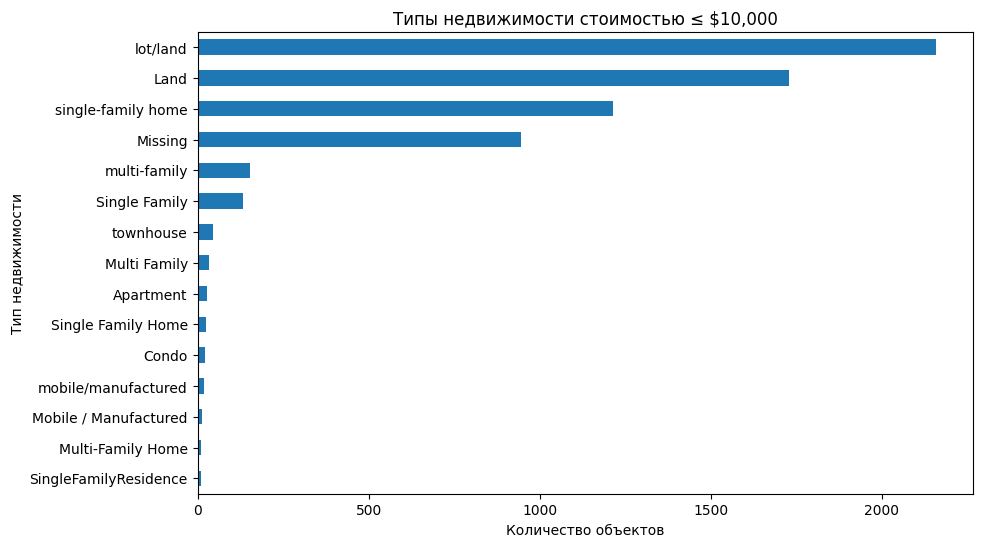

In [167]:
cheap_type = (
    cheap['propertyType']
    .fillna('Missing')
    .value_counts()
    .head(15)
)

display(cheap_type)

plt.figure(figsize=(10, 6))

cheap_type.sort_values().plot(kind='barh')

plt.title('Типы недвижимости стоимостью ≤ $10,000')
plt.xlabel('Количество объектов')
plt.ylabel('Тип недвижимости')
plt.show()

### Анализ выбросов целевой переменной

Анализ показал наличие значительного количества статистических выбросов стоимости. Однако применение стандартного IQR-метода для их автоматического удаления в данной задаче нецелесообразно.

Исследование наиболее дорогих объектов показало, что экстремальные значения преимущественно относятся к крупным объектам элитной недвижимости в Los Angeles, Beverly Hills и New York. Их характеристики согласуются с высокой стоимостью, поэтому верхний хвост распределения был сохранён.

Отдельного анализа требуют аномально низкие значения стоимости. В частности, в датасете присутствуют объекты стоимостью $1 и другие крайне низкие значения. При этом значительная часть дешёвых объектов относится к категории земельных участков, поэтому нижние значения нельзя удалять исключительно на основании статистического критерия.

Следующий шаг: отделяем продажу от аренды

Сначала выясним структуру status.

In [168]:
print(
    data['status']
    .value_counts(dropna=False)
    .head(50)
)

status
for sale                             156054
Active                               105206
For sale                              43464
NaN                                   39256
foreclosure                            5677
New construction                       5458
Pending                                4697
Pre-foreclosure                        2000
P                                      1488
Pre-foreclosure / auction              1281
Under Contract Show                    1183
 / auction                              799
Under Contract   Showing                793
Active Under Contract                   718
Under Contract                          690
New                                     690
Contingent                              581
Price Change                            563
Auction                                 493
A Active                                443
for rent                                398
Foreclosure                             343
Foreclosed               

И отдельно найдём объявления, где target содержит /mo:

In [169]:
rent_mask = (
    data['target']
    .astype('string')
    .str.contains(
        r'/mo|month|monthly',
        case=False,
        na=False,
        regex=True
    )
)

print('Объявлений с месячной арендой:', rent_mask.sum())

display(
    data.loc[
        rent_mask,
        [
            'target',
            'status',
            'propertyType',
            'city',
            'state',
            'sqft',
            'beds',
            'baths'
        ]
    ].head(30)
)

Объявлений с месячной арендой: 398


,target,status,propertyType,city,state,sqft,beds,baths
547,"$5,500/mo",for rent,single-family home,Chicago,IL,"3,300 sqft",4 Beds,3.5 Baths
609,"$10,500/mo",for rent,multi-family,Boston,MA,"1,673 sqft",2 Beds,2 Baths
2075,"$6,390/mo",for rent,single-family home,Fort Lauderdale,FL,"2,400 sqft",4 Beds,4 Baths
3025,"$1,200/mo",for rent,multi-family,Clarksville,TN,"1,280 sqft",2 Beds,2.5 Baths
3645,"$3,600/mo",for rent,multi-family,Chicago,IL,"1,473 sqft",2 Beds,2 Baths
4613,"$5,500/mo",for rent,townhouse,The Woodlands,TX,"3,657 sqft",3 Beds,3.5 Baths
5515,"$1,200/mo",for rent,single-family home,Lehigh Acres,FL,"1,408 sqft",3 Beds,2 Baths
6837,"$1,200/mo",for rent,single-family home,Philadelphia,PA,"1,548 sqft",NaN,NaN
8167,"$3,250/mo",for rent,single-family home,Orlando,FL,"4,036 sqft",5 Beds,4 Baths
8384,"$1,400/mo",for rent,single-family home,Houston,TX,"1,298 sqft",3 Beds,2 Baths


Также проверим, сколько записей прямо имеют rental-status:

In [170]:
rent_status_mask = (
    data['status']
    .astype('string')
    .str.contains(
        r'rent|lease',
        case=False,
        na=False,
        regex=True
    )
)

print(
    'Объявлений с rent/lease в status:',
    rent_status_mask.sum()
)

display(
    data.loc[
        rent_status_mask,
        ['target', 'status', 'propertyType', 'city', 'state']
    ].head(30)
)

Объявлений с rent/lease в status: 424


,target,status,propertyType,city,state
547,"$5,500/mo",for rent,single-family home,Chicago,IL
609,"$10,500/mo",for rent,multi-family,Boston,MA
2075,"$6,390/mo",for rent,single-family home,Fort Lauderdale,FL
3025,"$1,200/mo",for rent,multi-family,Clarksville,TN
3645,"$3,600/mo",for rent,multi-family,Chicago,IL
4613,"$5,500/mo",for rent,townhouse,The Woodlands,TX
5515,"$1,200/mo",for rent,single-family home,Lehigh Acres,FL
5873,"$1,250",Apartment for rent,Apartment,Hollywood,FL
6837,"$1,200/mo",for rent,single-family home,Philadelphia,PA
8167,"$3,250/mo",for rent,single-family home,Orlando,FL


И главное — пересечение:

In [171]:
print(
    'Rent по target:',
    rent_mask.sum()
)

print(
    'Rent/lease по status:',
    rent_status_mask.sum()
)

print(
    'Хотя бы один признак аренды:',
    (rent_mask | rent_status_mask).sum()
)

Rent по target: 398
Rent/lease по status: 424
Хотя бы один признак аренды: 424


3.12. Удаляем объявления об аренде

In [172]:
# Количество строк до удаления
rows_before = len(data)

# Удаляем rental / lease объявления
data = data.loc[~rent_status_mask].copy()

rows_after = len(data)

print('До удаления:', rows_before)
print('После удаления:', rows_after)
print('Удалено rental-объявлений:', rows_before - rows_after)

До удаления: 374655
После удаления: 374231
Удалено rental-объявлений: 424


### Очистка целевой переменной от объявлений об аренде

Анализ признаков `target` и `status` показал, что датасет содержит как объявления о продаже недвижимости, так и небольшое количество объявлений об аренде.

По тексту целевой переменной было обнаружено 398 объявлений с указанием месячной арендной платы. Анализ `status` выявил 424 объявления со статусами, связанными с арендой (`rent`/`lease`).

Поскольку целью проекта является прогнозирование стоимости недвижимости при продаже, смешивание цены продажи и месячной арендной платы привело бы к некорректному обучению модели.

Поэтому 424 объявления об аренде были исключены из дальнейшего анализа.

### 4. Переходим к признакам недвижимости

In [173]:
cols = ['sqft', 'beds', 'baths', 'stories']

for col in cols:
    print('\n' + '=' * 70)
    print(col.upper())
    print('=' * 70)

    print('Тип:', data[col].dtype)
    print('Пропусков:', data[col].isna().sum())
    print('Уникальных:', data[col].nunique())

    print('\nТОП-30 значений:')
    display(
        data[col]
        .value_counts(dropna=False)
        .head(30)
    )


SQFT
Тип: object
Пропусков: 40075
Уникальных: 25369

ТОП-30 значений:


sqft
NaN           40075
0             11853
1,200 sqft      824
1,000 sqft      643
1,100 sqft      566
1,800 sqft      558
1,500 sqft      544
--              535
2,000 sqft      516
1,400 sqft      515
1,600 sqft      451
800 sqft        449
1,300 sqft      403
900 sqft        402
1,440 sqft      374
2,400 sqft      370
2,200 sqft      359
960 sqft        358
1,200           357
3,000 sqft      341
2,100 sqft      322
1,152 sqft      309
1,120 sqft      303
1,700 sqft      300
1,500           298
1,344 sqft      292
1,250 sqft      289
750 sqft        287
2,500 sqft      285
960             284
Name: count, dtype: int64


BEDS
Тип: object
Пропусков: 90882
Уникальных: 1146

ТОП-30 значений:


beds
NaN       90882
3 Beds    52942
4 Beds    35143
3         31188
2 Beds    26077
4         19915
2         15997
Baths     15258
3 bd      12678
5 Beds    11204
4 bd       8193
3.0        8082
5          6392
4.0        5224
2 bd       5162
1          4582
6 Beds     3784
5 bd       2619
2.0        2428
6          1792
5.0        1371
0          1207
7 Beds     1095
1 bd       1066
-- bd       844
8 Beds      754
Bath        737
6 bd        643
7           510
1.0         429
Name: count, dtype: int64


BATHS
Тип: object
Пропусков: 105250
Уникальных: 225

ТОП-30 значений:


baths
NaN             105250
2 Baths          51945
3 Baths          35353
2                20427
2.0              16354
4 Baths          14711
3.0              10796
3                10090
Bathrooms: 2      9410
2.5               8110
Bathrooms: 3      6569
1                 6568
1.0               5798
5 Baths           5365
4.0               4559
2.5 Baths         4388
0                 3811
4                 3561
3.5               3452
Bathrooms: 1      3125
2 ba              2679
6 Baths           2598
Bathrooms: 4      2372
1,500             2207
3 ba              1884
1.5               1856
2,000             1792
3.5 Baths         1784
1,750             1720
3,000             1684
Name: count, dtype: int64


STORIES
Тип: object
Пропусков: 149341
Уникальных: 347

ТОП-30 значений:


stories
NaN              149341
1.0               66805
2.0               55002
1                 22792
2                 17972
3.0               11230
0.0                7209
One                5758
0                  4231
3                  4201
9.0                2914
2.00               2775
Two                2495
4.0                2136
2 Story            1968
1 Story            1252
1.00               1200
4                   888
3+                  868
6.0                 716
1.50                650
5.0                 614
Three Or More       569
3.00                517
9                   467
One Story           395
Lot                 365
Townhouse           325
7.0                 312
Ranch/1 Story       293
Name: count, dtype: int64

И отдельно посмотрим homeFacts, потому что там могут находиться признаки, которые помогут восстановить/дополнить sqft, год постройки, отопление, parking и т. д.:

In [174]:
pd.set_option('display.max_colwidth', None)

for i, value in enumerate(data['homeFacts'].head(10)):
    print(f'\nOBJECT {i}')
    print(value)



OBJECT 0
{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}

OBJECT 1
{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '5828 sqft', 'factLabel': 'lotsize'}, {'factValue': '$159/sqft', 'factLabel': 'Price/sqft'}]}

OBJECT 2
{'atAGlanceFacts': [{'factValue': '1961', 'factLabel': 'Year built'}, {'factValue': '1967', 'factLabel': 'Remodeled year'}, {'factValue': 'Forced Air', 'factLabel': 'Heating'}, {'factValue': 'Central', 'factLabel': 'Cooling'}, {'factValue': 'Atta

#### Очистка и Feature Engineering признаков


Первичный анализ показал, что ряд количественных характеристик недвижимости (`sqft`, `beds`, `baths`, `stories`) хранится в строковом формате и содержит различные единицы измерения и текстовые обозначения.

Кроме того, столбец `homeFacts` содержит вложенную структуру с дополнительными характеристиками объекта: год постройки, год реконструкции, отопление, охлаждение, парковка, площадь участка и стоимость квадратного фута.

На данном этапе выполним преобразование исходных признаков и извлечение дополнительной информации.

Признак `Price/sqft` не будет использоваться для обучения модели, поскольку он непосредственно зависит от стоимости объекта и может привести к утечке целевой переменной (target leakage).

4.1. Сначала нормально распарсим homeFacts

Строка выглядит как Python-словарь, поэтому используем ast.literal_eval, а не eval():

In [175]:
import ast
import numpy as np
import pandas as pd


def parse_home_facts(value):
    """Преобразует homeFacts в словарь factLabel -> factValue."""
    
    if pd.isna(value):
        return {}
    
    try:
        obj = ast.literal_eval(str(value))
        
        facts = obj.get('atAGlanceFacts', [])
        
        return {
            item.get('factLabel'): item.get('factValue')
            for item in facts
            if isinstance(item, dict)
        }
    
    except (ValueError, SyntaxError, TypeError):
        return {}


home_facts_parsed = data['homeFacts'].apply(parse_home_facts)

home_facts_parsed.head()

0                               {'Year built': '2019', 'Remodeled year': '', 'Heating': 'Central A/C, Heat Pump', 'Cooling': '', 'Parking': '', 'lotsize': None, 'Price/sqft': '$144'}
1                                         {'Year built': '2019', 'Remodeled year': '', 'Heating': '', 'Cooling': '', 'Parking': '', 'lotsize': '5828 sqft', 'Price/sqft': '$159/sqft'}
2    {'Year built': '1961', 'Remodeled year': '1967', 'Heating': 'Forced Air', 'Cooling': 'Central', 'Parking': 'Attached Garage', 'lotsize': '8,626 sqft', 'Price/sqft': '$965/sqft'}
3    {'Year built': '2006', 'Remodeled year': '2006', 'Heating': 'Forced Air', 'Cooling': 'Central', 'Parking': 'Detached Garage', 'lotsize': '8,220 sqft', 'Price/sqft': '$371/sqft'}
4                                                  {'Year built': '', 'Remodeled year': '', 'Heating': '', 'Cooling': '', 'Parking': '', 'lotsize': '10,019 sqft', 'Price/sqft': None}
Name: homeFacts, dtype: object

Теперь извлекаем признаки:

In [176]:
data['year_built_raw'] = home_facts_parsed.apply(
    lambda x: x.get('Year built')
)

data['remodeled_year_raw'] = home_facts_parsed.apply(
    lambda x: x.get('Remodeled year')
)

data['heating'] = home_facts_parsed.apply(
    lambda x: x.get('Heating')
)

data['cooling'] = home_facts_parsed.apply(
    lambda x: x.get('Cooling')
)

data['parking'] = home_facts_parsed.apply(
    lambda x: x.get('Parking')
)

data['lotsize_raw'] = home_facts_parsed.apply(
    lambda x: x.get('lotsize')
)

data['price_sqft_raw'] = home_facts_parsed.apply(
    lambda x: x.get('Price/sqft')
)

In [177]:
display(
    data[
        [
            'year_built_raw',
            'remodeled_year_raw',
            'heating',
            'cooling',
            'parking',
            'lotsize_raw',
            'price_sqft_raw'
        ]
    ].head(10)
)

,year_built_raw,remodeled_year_raw,heating,cooling,parking,lotsize_raw,price_sqft_raw
0,2019,,"Central A/C, Heat Pump",,,None,$144
1,2019,,,,,5828 sqft,$159/sqft
2,1961,1967,Forced Air,Central,Attached Garage,"8,626 sqft",$965/sqft
3,2006,2006,Forced Air,Central,Detached Garage,"8,220 sqft",$371/sqft
4,,,,,,"10,019 sqft",None
5,1920,,Forced Air,Central,,680 sqft,$233/sqft
6,2006,2006,"Electric, Heat Pump",Central Air,,"4,996 Sq. Ft.",$120 / Sq. Ft.
7,1976,,,,,"8,750 Sq. Ft.",$57 / Sq. Ft.
8,1970,,Forced Air,Central,,124582,$68
9,2019,None,Gas,Central,Attached Garage,"2,056 sqft",$162


4.2. Год постройки и реконструкции

In [178]:
data['year_built'] = pd.to_numeric(
    data['year_built_raw'],
    errors='coerce'
)

data['remodeled_year'] = pd.to_numeric(
    data['remodeled_year_raw'],
    errors='coerce'
)

Теперь уберём явно невозможные годы.

In [179]:
CURRENT_YEAR = 2026

data.loc[
    ~data['year_built'].between(1700, CURRENT_YEAR),
    'year_built'
] = np.nan

data.loc[
    ~data['remodeled_year'].between(1700, CURRENT_YEAR),
    'remodeled_year'
] = np.nan

In [180]:
display(
    data[['year_built', 'remodeled_year']].describe()
)

,year_built,remodeled_year
count,311014.000000,149558.000000
mean,1979.347698,1982.745209
std,33.598622,24.919531
min,1700.000000,1738.000000
25%,1957.000000,1968.000000
50%,1985.000000,1986.000000
75%,2007.000000,2004.000000
max,2025.000000,2021.000000


4.3. Очищаем sqft

Создадим отдельную функцию:

In [181]:
import re


def parse_sqft(value):
    """Преобразует площадь жилья в числовой формат sqft."""
    
    if pd.isna(value):
        return np.nan
    
    text = str(value).lower().strip()
    
    if text in ['', '--', 'nan', 'none', 'n/a']:
        return np.nan
    
    # Удаляем запятые
    text = text.replace(',', '')
    
    match = re.search(r'\d+(?:\.\d+)?', text)
    
    if not match:
        return np.nan
    
    value_num = float(match.group())
    
    # Нулевая площадь не несёт полезной информации
    if value_num <= 0:
        return np.nan
    
    return value_num

In [182]:
data['sqft_clean'] = data['sqft'].apply(parse_sqft)

In [183]:
display(
    data[
        ['sqft', 'sqft_clean']
    ].sample(20, random_state=42)
)

,sqft,sqft_clean
280606,"1,414 sqft",1414.0
348693,"1,000 sqft",1000.0
9475,"2,922 sqft",2922.0
183118,"1,825 sqft",1825.0
115606,0,NaN
48455,"1,561",1561.0
333720,"2,490 sqft",2490.0
296597,"2,192",2192.0
223094,"1,420",1420.0
68772,"2,401 sqft",2401.0


In [184]:
data['sqft_clean'].describe(
    percentiles=[0.01, 0.5, 0.95, 0.99]
)

count    3.214920e+05
mean     6.897054e+03
std      1.618633e+06
min      1.000000e+00
1%       5.680000e+02
50%      1.841000e+03
95%      4.798000e+03
99%      9.860450e+03
max      7.959794e+08
Name: sqft_clean, dtype: float64

4.4. beds и baths

Используем более строгий parser:

In [186]:
def parse_room_count(value):
    """Извлекает количество комнат/ванных из корректных значений."""
    
    if pd.isna(value):
        return np.nan
    
    text = str(value).lower().strip()
    
    if text in ['', '--', 'nan', 'none', 'n/a']:
        return np.nan
    
    # Это явно площадь, а не количество комнат
    bad_units = [
        'acre',
        'sqft',
        'sq ft',
        'square',
        'lot'
    ]
    
    if any(unit in text for unit in bad_units):
        return np.nan
    
    text = text.replace(',', '')
    
    match = re.search(r'\d+(?:\.\d+)?', text)
    
    if not match:
        return np.nan
    
    number = float(match.group())
    
    # Защита от очевидно ошибочных значений
    if number < 0 or number > 50:
        return np.nan
    
    return number

Применяем:

In [187]:
data['beds_clean'] = data['beds'].apply(parse_room_count)

data['baths_clean'] = data['baths'].apply(parse_room_count)

In [188]:
display(
    data[
        ['beds', 'beds_clean', 'baths', 'baths_clean']
    ].sample(30, random_state=42)
)

,beds,beds_clean,baths,baths_clean
280606,3 Beds,3.0,2.5 Baths,2.5
348693,2 Beds,2.0,NaN,NaN
9475,4 Beds,4.0,3 Baths,3.0
183118,3 Beds,3.0,2 Baths,2.0
115606,NaN,NaN,0,0.0
48455,NaN,NaN,NaN,NaN
333720,3 Beds,3.0,3 Baths,3.0
296597,3,3.0,3.0,3.0
223094,3,3.0,2.0,2.0
68772,3 Beds,3.0,4 Baths,4.0


In [189]:
display(
    data[
        ['beds_clean', 'baths_clean']
    ].describe(
        percentiles=[0.01, 0.5, 0.95, 0.99]
    )
)

,beds_clean,baths_clean
count,263134.000000,252882.000000
mean,3.350544,2.753580
std,1.388491,1.441485
min,0.000000,0.000000
1%,1.000000,0.000000
50%,3.000000,2.500000
95%,5.000000,5.000000
99%,8.000000,8.000000
max,48.000000,44.000000


4.5. stories пока не преобразовываем

stories имеет 347 уникальных вариантов. Там могут находиться:

In [190]:
display(
    data['stories']
    .value_counts(dropna=False)
    .head(50)
)

stories
NaN                    149341
1.0                     66805
2.0                     55002
1                       22792
2                       17972
3.0                     11230
0.0                      7209
One                      5758
0                        4231
3                        4201
9.0                      2914
2.00                     2775
Two                      2495
4.0                      2136
2 Story                  1968
1 Story                  1252
1.00                     1200
4                         888
3+                        868
6.0                       716
1.50                      650
5.0                       614
Three Or More             569
3.00                      517
9                         467
One Story                 395
Lot                       365
Townhouse                 325
7.0                       312
Ranch/1 Story             293
6                         282
Multi/Split               271
8.0                       254
Tw

4.6. Площадь участка lotsize

In [191]:
def parse_lotsize(value):
    """Преобразует площадь участка в квадратные футы."""
    
    if pd.isna(value):
        return np.nan
    
    text = str(value).lower().strip()
    
    if text in ['', '--', 'nan', 'none', 'n/a']:
        return np.nan
    
    text = text.replace(',', '')
    
    match = re.search(r'\d+(?:\.\d+)?', text)
    
    if not match:
        return np.nan
    
    number = float(match.group())
    
    # 1 acre = 43,560 sqft
    if 'acre' in text:
        number *= 43560
    
    if number <= 0:
        return np.nan
    
    return number

In [192]:
data['lotsize_sqft'] = (
    data['lotsize_raw']
    .apply(parse_lotsize)
)

In [193]:
display(
    data[
        ['lotsize_raw', 'lotsize_sqft']
    ].sample(30, random_state=42)
)

,lotsize_raw,lotsize_sqft
280606,,NaN
348693,,NaN
9475,"6,273 sqft",6273.0
183118,"10,106 sqft",10106.0
115606,22913,22913.0
48455,—,NaN
333720,2674 sqft,2674.0
296597,None,NaN
223094,"5,401 sqft",5401.0
68772,0.44 acres,19166.4


4.7. Price/sqft — важная утечка данных

Мы можем распарсить этот признак для EDA, но не включать его в X.

#### Предотвращение утечки целевой переменной

В `homeFacts` присутствует характеристика `Price/sqft`. Данный показатель не был включён в набор признаков модели, поскольку он рассчитывается с использованием стоимости объекта недвижимости.

Использование такого признака привело бы к target leakage: модель получила бы информацию о целевой переменной ещё до выполнения прогнозирования. Это могло бы искусственно значительно повысить показатели качества на тестовой выборке, но такая модель не была бы корректно применима к новым объектам с неизвестной ценой.

4.8. Heating, Cooling и Parking

Не выбрасываем их. Это потенциально полезные категориальные признаки.

In [194]:
for col in ['heating', 'cooling', 'parking']:
    
    print('\n', col.upper())
    
    display(
        data[col]
        .value_counts(dropna=False)
        .head(20)
    )


 HEATING


heating
                         104899
Forced Air                82353
Forced air                51110
Other                     29054
Electric                  10167
Gas                        9258
No Data                    8415
Central Air                7814
Central Electric           7111
Central                    6245
Heat Pump                  6076
Central, Electric          4251
Baseboard                  3770
None                       3485
Wall                       3277
Electric Heat              3064
Heat pump                  2730
Heating System             2709
Forced air, Heat pump      1724
Radiant                    1481
Name: count, dtype: int64


 COOLING


cooling
Central                                            157618
                                                   119150
Central Air                                         14382
No Data                                             10395
Has Cooling                                          9729
None                                                 7291
Central Electric                                     6151
Wall                                                 3982
Central Gas                                          3573
None                                                 3485
Central Heating                                      2807
Cooling System                                       2700
Central A/C                                          2051
Other                                                1787
Central A/C (Electric), Central Heat (Gas)           1646
Central A/C (Electric), Central Heat (Electric)      1429
Refrigeration                                        1061
Centra


 PARKING


parking
                                    170782
Attached Garage                      70240
2 spaces                             27863
1 space                              14102
Detached Garage                      13092
No Data                              13022
Carport                               7663
3 spaces                              4702
Off Street                            3563
None                                  3485
Carport, Attached Garage              3006
1                                     2928
4 spaces                              2899
2                                     2745
None                                  2342
Off street                            1637
Attached Garage, Detached Garage      1334
On Street                             1237
0                                     1114
Attached Garage, Carport               987
Name: count, dtype: int64

4.9. Очистка аномалий sqft

Не будем механически использовать IQR: luxury homes могут иметь 15,000–50,000 sqft.

Сначала исследуем крайние значения:

In [195]:
print('Объектов sqft > 20,000:',
      (data['sqft_clean'] > 20000).sum())

print('Объектов sqft > 50,000:',
      (data['sqft_clean'] > 50000).sum())

print('Объектов sqft > 100,000:',
      (data['sqft_clean'] > 100000).sum())

print('\nСамые большие значения:')

display(
    data[
        [
            'sqft',
            'sqft_clean',
            'target_clean',
            'propertyType',
            'city',
            'state',
            'beds_clean',
            'baths_clean'
        ]
    ]
    .sort_values('sqft_clean', ascending=False)
    .head(30)
)

Объектов sqft > 20,000: 1596
Объектов sqft > 50,000: 1053
Объектов sqft > 100,000: 716

Самые большие значения:


,sqft,sqft_clean,target_clean,propertyType,city,state,beds_clean,baths_clean
62736,"795,979,430 sqft",795979430.0,27500,single-family home,Cincinnati,OH,2.0,2.0
376529,456602479,456602479.0,198000,Multi-Family Home,Glendale,KY,NaN,NaN
74215,"7,078,574 sqft",7078574.0,98000,lot/land,Laredo,TX,NaN,NaN
142148,"5,728,968 sqft",5728968.0,289000,lot/land,Yakima,WA,NaN,NaN
187391,"4,356,000 sqft",4356000.0,400000,lot/land,Panama City,FL,NaN,NaN
52217,"4,356,000 sqft",4356000.0,2000000,lot/land,Von Ormy,TX,NaN,NaN
232326,"2,807,917 sqft",2807917.0,114900,lot/land,San Antonio,TX,NaN,NaN
354884,"2,807,917",2807917.0,114900,NaN,San Antonio,TX,NaN,NaN
233864,"2,613,600 sqft",2613600.0,230000,lot/land,Panama City,FL,NaN,NaN
37394,"2,585,006 sqft",2585006.0,138000,lot/land,San Antonio,TX,NaN,NaN


4.10. Beds и baths

In [196]:
display(
    data[
        [
            'target_clean',
            'propertyType',
            'city',
            'state',
            'sqft_clean',
            'beds',
            'beds_clean',
            'baths',
            'baths_clean'
        ]
    ]
    .sort_values('beds_clean', ascending=False)
    .head(20)
)

,target_clean,propertyType,city,state,sqft_clean,beds,beds_clean,baths,baths_clean
123697,2189000,multi-family,Charlotte,NC,16675.0,48 Beds,48.0,22 Baths,22.0
32808,2189000,Multi-Family Home,Charlotte,NC,16675.0,48,48.0,22,22.0
224298,10000000,multi-family,North Hills,CA,28742.0,47 Beds,47.0,39 Baths,39.0
54705,2790000,multi-family,Los Angeles,CA,2633.0,47 Beds,47.0,29 Baths,29.0
300701,1175000,Multi Family,Springfield,MA,3760.0,46 bd,46.0,Bathrooms: 16,16.0
138450,5900000,multi-family,Los Angeles,CA,23987.0,44 Beds,44.0,23 Baths,23.0
305415,5900000,Multi-Family Home,Los Angeles,CA,23987.0,44,44.0,23,23.0
65253,350000,single-family home,Corinth,TX,2689.0,44 Beds,44.0,3 Baths,3.0
258978,7750000,single-family home,Valley Glen,CA,18770.0,42 Beds,42.0,42 Baths,42.0
261667,1650000,single-family home,Flushing,NY,3840.0,42 Beds,42.0,5 Baths,5.0


In [197]:
display(
    data[
        [
            'target_clean',
            'propertyType',
            'city',
            'state',
            'sqft_clean',
            'beds_clean',
            'baths_clean'
        ]
    ]
    .sort_values('baths_clean', ascending=False)
    .head(20)
)

,target_clean,propertyType,city,state,sqft_clean,beds_clean,baths_clean
363608,10700000,multi-family,Los Angeles,CA,28824.0,NaN,44.0
122038,20000000,multi-family,Boston,MA,21210.0,NaN,44.0
360980,20000000,Multi Family,Boston,MA,21210.0,NaN,44.0
98160,18500000,multi-family,Flushing,NY,22600.0,32.0,43.0
258978,7750000,single-family home,Valley Glen,CA,18770.0,42.0,42.0
147176,2590000,Condo,Miami Beach,FL,5101.0,4.0,41.0
253239,7495000,Multi-Family Home,Los Angeles,CA,22720.0,40.0,40.0
69429,4500000,Multi-Family Home,Denver,CO,16506.0,30.0,40.0
21468,1704000,multi-family,Lauderhill,FL,1100.0,32.0,40.0
280333,6360000,multi-family,Los Angeles,CA,29096.0,NaN,40.0


4.11. Обрабатываем stories

Здесь можно сделать хороший парсер. Нам нужны:

In [198]:
def parse_stories(value):
    """Преобразует количество этажей в числовой формат."""

    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip()

    if text in ['', '--', 'nan', 'none', 'n/a']:
        return np.nan

    word_mapping = {
        'one': 1.0,
        'one level': 1.0,
        'single': 1.0,
        'single level': 1.0,
        'two': 2.0,
        'two story': 2.0,
        'two stories': 2.0,
        'three': 3.0,
        'three story': 3.0,
        'three stories': 3.0,
        'three or more': 3.0
    }

    if text in word_mapping:
        return word_mapping[text]

    # "2 Story", "1 Story", "3+", "1.50"
    match = re.search(r'\d+(?:\.\d+)?', text)

    if match:
        number = float(match.group())

        # Защита от явно ошибочных значений
        if 0 <= number <= 100:
            return number

    return np.nan


data['stories_clean'] = data['stories'].apply(parse_stories)

In [199]:
display(
    data[['stories', 'stories_clean']]
    .sample(30, random_state=42)
)

,stories,stories_clean
280606,2.0,2.0
348693,1.0,1.0
9475,2.0,2.0
183118,1.0,1.0
115606,NaN,NaN
48455,NaN,NaN
333720,2.0,2.0
296597,0.0,0.0
223094,1.0,1.0
68772,2.0,2.0


In [200]:
display(
    data['stories_clean'].describe(
        percentiles=[0.01, 0.5, 0.95, 0.99]
    )
)

count    221782.000000
mean          1.906016
std           2.854679
min           0.000000
1%            0.000000
50%           1.500000
95%           3.000000
99%           9.000000
max          96.000000
Name: stories_clean, dtype: float64

4.12. Нормализуем Heating

In [201]:
def normalize_category(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if text in ['', 'none', 'no data', 'nan', 'n/a']:
        return np.nan

    return text


data['heating_clean'] = data['heating'].apply(normalize_category)
data['cooling_clean'] = data['cooling'].apply(normalize_category)
data['parking_clean'] = data['parking'].apply(normalize_category)

In [202]:
print('Heating categories:',
      data['heating_clean'].nunique())

print('Cooling categories:',
      data['cooling_clean'].nunique())

print('Parking categories:',
      data['parking_clean'].nunique())

Heating categories: 1903
Cooling categories: 1433
Parking categories: 3314


In [203]:
display(data['heating_clean'].value_counts().head(20))
display(data['cooling_clean'].value_counts().head(20))
display(data['parking_clean'].value_counts().head(20))

heating_clean
forced air                     133463
other                           29054
electric                        10173
gas                              9261
heat pump                        8806
central air                      7814
central electric                 7111
central                          6245
central, electric                4251
baseboard                        3770
wall                             3277
electric heat                    3064
heating system                   2709
forced air, heat pump            1764
radiant                          1481
central air, ceiling fan(s)      1431
natural gas heat                 1383
central furnace                  1036
forced air, gas                   959
central electric, zoned           873
Name: count, dtype: int64

cooling_clean
central                                            157618
central air                                         14382
has cooling                                          9729
central electric                                     6151
wall                                                 3982
central gas                                          3573
central heating                                      2807
cooling system                                       2700
central a/c                                          2051
other                                                1787
central a/c (electric), central heat (gas)           1646
central a/c (electric), central heat (electric)      1429
refrigeration                                        1061
central, electric                                    1059
electric                                             1009
evaporative                                           987
central air, gas hot air/furnace                      827


parking_clean
attached garage                     70240
2 spaces                            27863
1 space                             14102
detached garage                     13092
carport                              7663
off street                           5200
3 spaces                             4702
carport, attached garage             3006
1                                    2928
4 spaces                             2899
2                                    2745
on street                            1697
attached garage, detached garage     1334
0                                    1114
attached garage, carport              987
parking desc                          900
6 spaces                              748
detached garage, attached garage      720
driveway                              693
5 spaces                              654
Name: count, dtype: int64

4.13. Создаём полезные признаки из года постройки

У нас есть хороший year_built.

Создадим возраст недвижимости относительно 2026 года:

In [204]:
data['property_age'] = 2026 - data['year_built']

data.loc[
    data['property_age'] < 0,
    'property_age'
] = np.nan

In [205]:
data['was_remodeled'] = (
    data['remodeled_year'].notna()
).astype(int)

In [206]:
data['years_to_remodel'] = (
    data['remodeled_year'] -
    data['year_built']
)

data.loc[
    data['years_to_remodel'] < 0,
    'years_to_remodel'
] = np.nan

In [207]:
display(
    data[
        [
            'year_built',
            'remodeled_year',
            'property_age',
            'was_remodeled',
            'years_to_remodel'
        ]
    ].describe()
)

,year_built,remodeled_year,property_age,was_remodeled,years_to_remodel
count,311014.000000,149558.000000,311014.000000,374231.000000,144769.000000
mean,1979.347698,1982.745209,46.652302,0.399641,9.867748
std,33.598622,24.919531,33.598622,0.489825,20.336081
min,1700.000000,1738.000000,1.000000,0.000000,0.000000
25%,1957.000000,1968.000000,19.000000,0.000000,0.000000
50%,1985.000000,1986.000000,41.000000,0.000000,0.000000
75%,2007.000000,2004.000000,69.000000,1.000000,10.000000
max,2025.000000,2021.000000,326.000000,1.000000,283.000000


In [208]:
# Убираем явно ошибочные значения площади,
# но сохраняем сами объекты недвижимости
data['sqft_clean'] = data['sqft_clean'].where(
    data['sqft_clean'].between(100, 100000)
)

print(data['sqft_clean'].describe())

count    320649.000000
mean       2307.407757
std        3065.562189
min         100.000000
25%        1299.000000
50%        1839.000000
75%        2620.000000
max      100000.000000
Name: sqft_clean, dtype: float64


Для цены недвижимости это один из самых очевидно важных признаков: дом, condo, земельный участок и townhouse имеют совершенно разную структуру цен.

In [209]:
def clean_property_type(value):
    if pd.isna(value):
        return 'unknown'

    text = str(value).lower()

    if 'single' in text:
        return 'single_family'
    elif 'condo' in text or 'co-op' in text:
        return 'condo'
    elif 'town' in text:
        return 'townhouse'
    elif 'multi' in text:
        return 'multi_family'
    elif 'land' in text or 'lot' in text:
        return 'land'
    elif 'mobile' in text or 'manufactured' in text:
        return 'mobile_home'
    elif 'apartment' in text:
        return 'apartment'
    else:
        return 'other'


data['propertyType_clean'] = (
    data['propertyType']
    .apply(clean_property_type)
)

data['propertyType_clean'].value_counts()

propertyType_clean
single_family    188356
condo             51094
unknown           34554
other             33602
land              31463
townhouse         18481
multi_family      12320
mobile_home        3552
apartment           809
Name: count, dtype: int64

### Вывод по предобработке признаков

В ходе предобработки строковые характеристики недвижимости были преобразованы в пригодный для моделирования формат. Из признака `homeFacts` были извлечены дополнительные характеристики: год постройки и реконструкции, отопление, охлаждение, парковка и площадь участка.

Площадь жилья, количество спален, ванных комнат и этажность были преобразованы в числовой формат. Явно некорректные значения площади были заменены пропусками без удаления самих объектов.

Категории типа недвижимости были объединены в основные группы. Признак `Price/sqft` был исключён из будущей модели, поскольку его использование привело бы к утечке целевой переменной.

Таким образом, после очистки сформирован набор основных характеристик недвижимости, который может быть использован для дальнейшего анализа и построения моделей машинного обучения.

### 5. Статистический анализ — для максимума по критерию

Гипотеза Цена недвижимости зависит от количества спален. Можно сравнить группы статистически.

Количество объектов для анализа: 257231


,beds_clean,count,median,mean
0,1,6083,257000.0,333542.09
1,2,49665,284480.0,426577.3
2,3,104892,286225.0,453244.39
3,4,68475,384900.0,667264.26
4,5,21586,639000.0,1308610.05
5,6,6530,899699.5,2153423.18


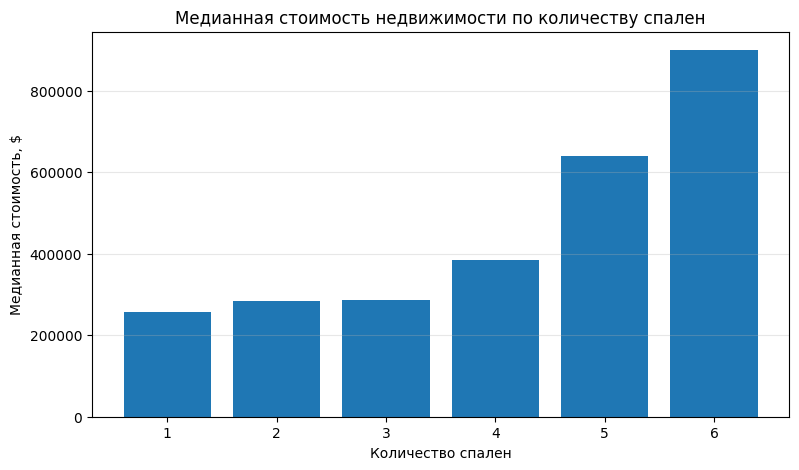


Гипотезы:
H0: распределение стоимости одинаково для объектов
    с разным количеством спален.
H1: стоимость хотя бы в одной группе статистически отличается.

Тест Шапиро—Уилка:


,beds,sample_size,shapiro_stat,p_value,normal_distribution
0,1,5000,0.386281,1.212866e-84,False
1,2,5000,0.455873,5.470511e-82,False
2,3,5000,0.307237,2.335568e-87,False
3,4,5000,0.230157,9.292739e-90,False
4,5,5000,0.327557,1.095773e-86,False
5,6,5000,0.383578,9.684390e-85,False



Тест Краскела—Уоллиса:
H-statistic: 28571.7979
p-value: 0
Вывод: отвергаем H0. Стоимость недвижимости статистически значимо различается в зависимости от количества спален.

Корреляция Спирмена:
rho: 0.2996
p-value: 0
Между количеством спален и стоимостью обнаружена статистически значимая положительная связь.


In [210]:
# ============================================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ:
# зависит ли стоимость недвижимости от количества спален?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, kruskal, spearmanr

# ------------------------------------------------------------
# 1. Подготовка данных
# ------------------------------------------------------------

stat_data = data[
    ['beds_clean', 'target_clean']
].dropna().copy()

# Оставляем типичные жилые объекты:
# 1–6 спален. Значения 0 могут относиться к земле,
# а редкие большие значения создают слишком малые группы.
stat_data = stat_data[
    stat_data['beds_clean'].between(1, 6)
].copy()

# Количество спален должно быть целым
stat_data = stat_data[
    stat_data['beds_clean'] % 1 == 0
].copy()

stat_data['beds_clean'] = stat_data['beds_clean'].astype(int)

print('Количество объектов для анализа:', len(stat_data))

# ------------------------------------------------------------
# 2. Описательная статистика
# ------------------------------------------------------------

bedroom_stats = (
    stat_data
    .groupby('beds_clean')['target_clean']
    .agg(
        count='count',
        median='median',
        mean='mean'
    )
    .reset_index()
)

bedroom_stats['median'] = bedroom_stats['median'].round(2)
bedroom_stats['mean'] = bedroom_stats['mean'].round(2)

display(bedroom_stats)

# ------------------------------------------------------------
# 3. Визуализация медианной цены
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    bedroom_stats['beds_clean'].astype(str),
    bedroom_stats['median']
)

plt.title('Медианная стоимость недвижимости по количеству спален')
plt.xlabel('Количество спален')
plt.ylabel('Медианная стоимость, $')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 4. Формулировка гипотез
# ------------------------------------------------------------

print('\nГипотезы:')
print('H0: распределение стоимости одинаково для объектов')
print('    с разным количеством спален.')
print('H1: стоимость хотя бы в одной группе статистически отличается.')

# ------------------------------------------------------------
# 5. Проверка нормальности
# ------------------------------------------------------------

# Shapiro ограничиваем случайной выборкой по 5000 объектов,
# поскольку на очень больших выборках тест чрезмерно чувствителен.
print('\nТест Шапиро—Уилка:')

normality_results = []

for beds, group in stat_data.groupby('beds_clean'):
    sample = group['target_clean']

    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)

    statistic, p_value = shapiro(sample)

    normality_results.append({
        'beds': beds,
        'sample_size': len(sample),
        'shapiro_stat': statistic,
        'p_value': p_value,
        'normal_distribution': p_value >= 0.05
    })

normality_df = pd.DataFrame(normality_results)

display(normality_df)

# ------------------------------------------------------------
# 6. Непараметрический тест Краскела—Уоллиса
# ------------------------------------------------------------

# Распределение цены сильно асимметрично, поэтому сравниваем
# независимые группы непараметрическим критерием.
groups = [
    group['target_clean'].to_numpy()
    for _, group in stat_data.groupby('beds_clean')
]

h_statistic, p_value = kruskal(*groups)

print('\nТест Краскела—Уоллиса:')
print(f'H-statistic: {h_statistic:.4f}')
print(f'p-value: {p_value:.6g}')

alpha = 0.05

if p_value < alpha:
    print(
        'Вывод: отвергаем H0. Стоимость недвижимости '
        'статистически значимо различается в зависимости '
        'от количества спален.'
    )
else:
    print(
        'Вывод: нет оснований отвергать H0. '
        'Статистически значимые различия не обнаружены.'
    )

# ------------------------------------------------------------
# 7. Дополнительная проверка направления связи
# ------------------------------------------------------------

rho, spearman_p = spearmanr(
    stat_data['beds_clean'],
    stat_data['target_clean']
)

print('\nКорреляция Спирмена:')
print(f'rho: {rho:.4f}')
print(f'p-value: {spearman_p:.6g}')

if spearman_p < alpha:
    if rho > 0:
        print(
            'Между количеством спален и стоимостью обнаружена '
            'статистически значимая положительная связь.'
        )
    else:
        print(
            'Между количеством спален и стоимостью обнаружена '
            'статистически значимая отрицательная связь.'
        )
else:
    print('Статистически значимая монотонная связь не обнаружена.')

### Вывод статистического анализа

Для проверки зависимости стоимости недвижимости от количества спален были рассмотрены объекты с 1–6 спальнями.

Описательная статистика показывает, что медианная стоимость недвижимости в целом увеличивается с ростом количества спален:

- 1 спальня — 257 000 долларов;
- 2 спальни — 284 480 долларов;
- 3 спальни — 286 225 долларов;
- 4 спальни — 384 900 долларов;
- 5 спален — 639 000 долларов;
- 6 спален — 899 699.5 доллара.

Проверка распределений стоимости с помощью критерия Шапиро–Уилка показала, что во всех группах p-value значительно меньше 0.05. Следовательно, распределения стоимости не являются нормальными.

По этой причине для сравнения независимых групп был применён непараметрический критерий Краскела–Уоллиса.

Результат теста:

- H-statistic = 28 571.80;
- p-value < 0.001.

Нулевая гипотеза об одинаковом распределении стоимости недвижимости для объектов с разным количеством спален отвергается. Следовательно, стоимость недвижимости статистически значимо различается в зависимости от количества спален.

Дополнительно был рассчитан коэффициент корреляции Спирмена:

- rho = 0.2996;
- p-value < 0.001.

Между количеством спален и стоимостью обнаружена статистически значимая положительная связь. При этом сила связи является умеренно слабой: количество спален связано с ценой, но не объясняет её полностью.

Полученный результат будет использован при моделировании: признак количества спален следует сохранить в наборе факторов. Однако интерпретировать эту связь как причинную нельзя, поскольку цена одновременно зависит от площади объекта, типа недвижимости, состояния и местоположения.

### 6. Корреляционный анализ

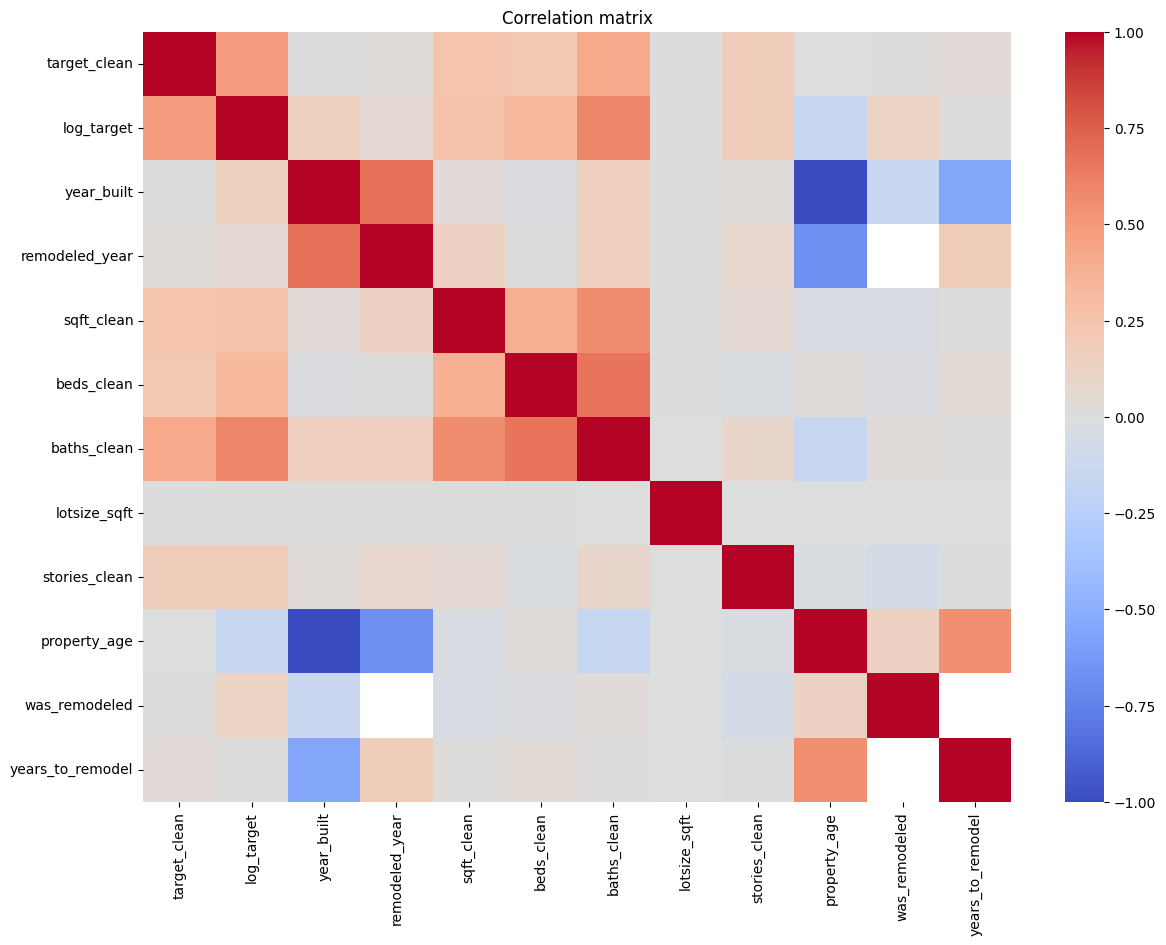

In [211]:
numeric_data = data.select_dtypes(include=np.number)

corr = numeric_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation matrix')
plt.show()

In [215]:
corr[TARGET].drop('log_target').sort_values(ascending=False)

target_clean        1.000000
baths_clean         0.420789
sqft_clean          0.251502
beds_clean          0.221245
stories_clean       0.173639
years_to_remodel    0.037858
remodeled_year      0.019484
was_remodeled       0.011293
year_built          0.005732
lotsize_sqft        0.002657
property_age       -0.005732
Name: target_clean, dtype: float64

### Вывод по корреляционному анализу

Для оценки линейной взаимосвязи между числовыми признаками была построена корреляционная матрица.

Наибольшую положительную корреляцию со стоимостью недвижимости имеют следующие признаки:

| Признак | Корреляция |
|---------|-----------:|
| log_target | 0.477 |
| baths_clean | 0.421 |
| sqft_clean | 0.252 |
| beds_clean | 0.221 |
| stories_clean | 0.174 |

Полученные результаты показывают, что наиболее сильная линейная связь наблюдается между стоимостью недвижимости и количеством ванных комнат. Умеренную положительную связь также имеют площадь дома, количество спален и этажность.

Признаки year_built, remodeled_year, lotsize_sqft и property_age практически не имеют линейной корреляции с ценой недвижимости.

При этом отсутствие высокой корреляции не означает, что признак бесполезен для модели. Многие современные алгоритмы машинного обучения (Random Forest, Gradient Boosting, CatBoost, LightGBM, XGBoost) способны выявлять нелинейные зависимости и сложные взаимодействия между признаками.

Корреляционный анализ также не выявил критически высокой корреляции между большинством признаков, поэтому их можно использовать совместно при построении моделей.

### 7. Feature Engineering

Ниже один полный блок:

формирует финальный набор признаков;

делит данные на train/test;

создаёт ColumnTransformer;

обучает DummyRegressor, LinearRegression, RandomForest;

при наличии библиотеки обучает CatBoost;

сравнивает модели по MAE, RMSE, R²;

обучает модели на логарифме цены, но считает метрики в долларах.

Размер данных для моделирования: (374231, 12)
Числовые признаки: ['sqft_clean', 'beds_clean', 'baths_clean', 'stories_clean', 'lotsize_sqft', 'year_built', 'remodeled_year', 'property_age', 'was_remodeled', 'years_to_remodel']
Категориальные признаки: ['propertyType_clean', 'state']

Train: (299384, 12)
Test: (74847, 12)

DummyRegressor
--------------------------------------------------
MAE:  $470,872.47
RMSE: $1,915,442.71
R²:   -0.0300

LinearRegression
--------------------------------------------------
MAE:  $6,970,055.41
RMSE: $944,540,036.36
R²:   -250455.7697

RandomForestRegressor
--------------------------------------------------
MAE:  $286,978.16
RMSE: $1,516,952.48
R²:   0.3540

Итоговое сравнение моделей:


,model,MAE,RMSE,R2
0,RandomForestRegressor,"$286,978.16","$1,516,952.48",0.3540
1,DummyRegressor,"$470,872.47","$1,915,442.71",-0.0300
2,LinearRegression,"$6,970,055.41","$944,540,036.36",-250455.7697


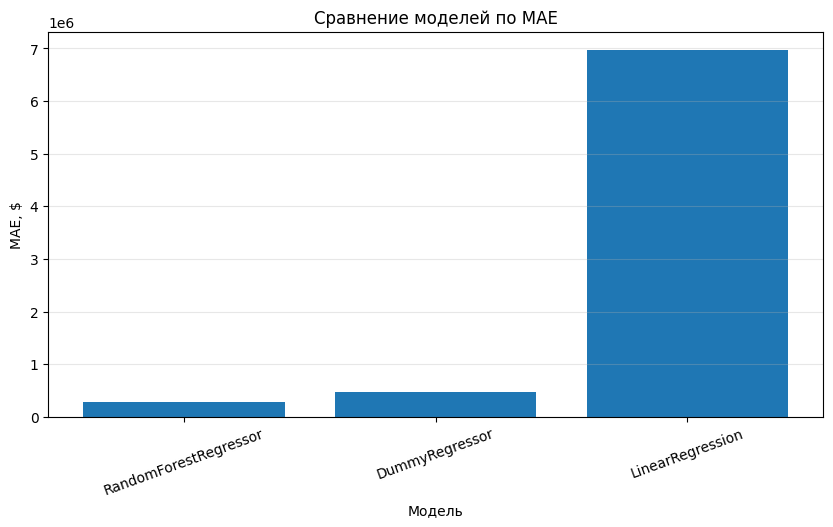

Лучшая модель по MAE: RandomForestRegressor


In [218]:
# ============================================================
# 7. ПОДГОТОВКА ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. Дополнительная короткая очистка
# ============================================================

# Явно некорректные площади заменяем пропусками
data['sqft_clean'] = data['sqft_clean'].where(
    data['sqft_clean'].between(100, 100000)
)


# Если propertyType_clean ещё не был создан
def clean_property_type(value):
    if pd.isna(value):
        return 'unknown'

    text = str(value).lower()

    if 'single' in text:
        return 'single_family'
    if 'condo' in text or 'co-op' in text:
        return 'condo'
    if 'town' in text:
        return 'townhouse'
    if 'multi' in text:
        return 'multi_family'
    if 'land' in text or 'lot' in text:
        return 'land'
    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_home'
    if 'apartment' in text:
        return 'apartment'

    return 'other'


if 'propertyType_clean' not in data.columns:
    data['propertyType_clean'] = (
        data['propertyType']
        .apply(clean_property_type)
    )


# ============================================================
# 2. Выбираем признаки
# ============================================================

numeric_features = [
    'sqft_clean',
    'beds_clean',
    'baths_clean',
    'stories_clean',
    'lotsize_sqft',
    'year_built',
    'remodeled_year',
    'property_age',
    'was_remodeled',
    'years_to_remodel'
]

categorical_features = [
    'propertyType_clean',
    'state'
]

features = numeric_features + categorical_features
TARGET = 'target_clean'


# Оставляем строки с известной положительной ценой
model_data = data[
    data[TARGET].notna() &
    (data[TARGET] > 0)
].copy()

# Бесконечные значения заменяем пропусками
model_data[numeric_features] = (
    model_data[numeric_features]
    .replace([np.inf, -np.inf], np.nan)
)

X = model_data[features].copy()
y = model_data[TARGET].astype(float).copy()

# Из-за сильной асимметрии обучаемся на log(1 + price)
y_log = np.log1p(y)

print('Размер данных для моделирования:', X.shape)
print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)


# ============================================================
# 3. Train/test split
# ============================================================

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

# Настоящие цены для расчёта метрик в долларах
y_test = np.expm1(y_test_log)

print('\nTrain:', X_train.shape)
print('Test:', X_test.shape)


# ============================================================
# 4. Предобработка признаков
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            RobustScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=100
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_transformer,
            numeric_features
        ),
        (
            'categorical',
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 5. Функция оценки
# ============================================================

def evaluate_model(model, X_test, y_test_log, model_name):
    """
    Получает предсказания логарифма цены,
    возвращает метрики в исходных долларах.
    """

    prediction_log = model.predict(X_test)

    # Возвращаем предсказания в исходную шкалу
    prediction = np.expm1(prediction_log)
    actual = np.expm1(y_test_log)

    # Цена не может быть отрицательной
    prediction = np.clip(prediction, 0, None)

    mae = mean_absolute_error(actual, prediction)
    rmse = np.sqrt(mean_squared_error(actual, prediction))
    r2 = r2_score(actual, prediction)

    print(f'\n{model_name}')
    print('-' * 50)
    print(f'MAE:  ${mae:,.2f}')
    print(f'RMSE: ${rmse:,.2f}')
    print(f'R²:   {r2:.4f}')

    return {
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }


results = []
trained_models = {}


# ============================================================
# 6. DummyRegressor — наивный baseline
# ============================================================

dummy_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DummyRegressor(strategy='median')
        )
    ]
)

dummy_pipeline.fit(X_train, y_train_log)

results.append(
    evaluate_model(
        dummy_pipeline,
        X_test,
        y_test_log,
        'DummyRegressor'
    )
)

trained_models['DummyRegressor'] = dummy_pipeline


# ============================================================
# 7. Linear Regression
# ============================================================

linear_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train_log)

results.append(
    evaluate_model(
        linear_pipeline,
        X_test,
        y_test_log,
        'LinearRegression'
    )
)

trained_models['LinearRegression'] = linear_pipeline


# ============================================================
# 8. Random Forest
# ============================================================

random_forest_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=150,
                max_depth=20,
                min_samples_leaf=3,
                max_features='sqrt',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train_log)

results.append(
    evaluate_model(
        random_forest_pipeline,
        X_test,
        y_test_log,
        'RandomForestRegressor'
    )
)

trained_models['RandomForestRegressor'] = random_forest_pipeline




# ============================================================
# 10. Сравнение моделей
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values('MAE')
    .reset_index(drop=True)
)

print('\nИтоговое сравнение моделей:')
display(
    results_df.style.format({
        'MAE': '${:,.2f}',
        'RMSE': '${:,.2f}',
        'R2': '{:.4f}'
    })
)


# ============================================================
# 11. Визуализация сравнения MAE
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results_df['model'],
    results_df['MAE']
)

plt.title('Сравнение моделей по MAE')
plt.xlabel('Модель')
plt.ylabel('MAE, $')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()


# ============================================================
# 12. Выбираем лучшую модель
# ============================================================

best_model_name = results_df.loc[0, 'model']
best_model = trained_models[best_model_name]

print('Лучшая модель по MAE:', best_model_name)

### Вывод по сравнению моделей

В качестве наивного baseline использовалась модель `DummyRegressor`,
предсказывающая медианное значение целевой переменной. Её средняя
абсолютная ошибка составила 470 872 доллара.

Модель `LinearRegression` показала неудовлетворительное качество.
Сильная асимметрия стоимости, выбросы и нелинейные зависимости между
характеристиками недвижимости не позволяют адекватно описать данные
простой линейной моделью.

Лучший результат показала модель `RandomForestRegressor`:

- MAE — 286 978 долларов;
- RMSE — 1 516 952 доллара;
- R² — 0.354.

По сравнению с наивным baseline средняя абсолютная ошибка уменьшилась
на 39.05%. Это подтверждает, что характеристики объектов недвижимости
содержат полезную информацию для прогнозирования цены.

В качестве итоговой модели выбрана `RandomForestRegressor`, поскольку
она показала минимальное значение MAE на отложенной тестовой выборке.

In [217]:
dummy_mae = results_df.loc[
    results_df['model'] == 'DummyRegressor',
    'MAE'
].iloc[0]

rf_mae = results_df.loc[
    results_df['model'] == 'RandomForestRegressor',
    'MAE'
].iloc[0]

improvement = (dummy_mae - rf_mae) / dummy_mae * 100

print(f'Улучшение относительно baseline: {improvement:.2f}%')

Улучшение относительно baseline: 39.05%


### 9. Сохранение модели

In [219]:
import pickle

MODEL_PATH = r'C:\DS\SF\Final project 26\real_estate_model.pkl'

with open(MODEL_PATH, 'wb') as file:
    pickle.dump(random_forest_pipeline, file)

print('Модель сохранена:', MODEL_PATH)

Модель сохранена: C:\DS\SF\Final project 26\real_estate_model.pkl


In [220]:
with open(MODEL_PATH, 'rb') as file:
    loaded_model = pickle.load(file)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


Проверка предсказания

Модель обучалась на логарифме цены, поэтому результат нужно вернуть в доллары через np.expm1():

In [221]:
sample_object = X_test.iloc[[0]]

prediction_log = loaded_model.predict(sample_object)[0]
prediction_price = np.expm1(prediction_log)

actual_price = np.expm1(y_test_log.iloc[0])

print(f'Прогноз: ${prediction_price:,.2f}')
print(f'Фактическая цена: ${actual_price:,.2f}')

Прогноз: $228,504.27
Фактическая цена: $308,990.00


### 10. Preprocessing Pipeline

Разделяем признаки:

In [222]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [223]:
numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            RobustScaler()
        )
    ]
)

In [224]:
categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [226]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

### 12. Сохранение модели


In [228]:
import pickle

with open("random_forest_pipeline.pkl", "wb") as f:
    pickle.dump(random_forest_pipeline, f)

print("Model saved.")

Model saved.


In [229]:
import pickle

with open("random_forest_pipeline.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


## Общий вывод

Целью проекта была разработка модели машинного обучения для прогнозирования стоимости объектов недвижимости на основе истории объявлений.

В ходе работы были проведены исследовательский анализ данных, очистка набора данных, обработка пропусков, удаление нерелевантных объявлений, извлечение новых признаков и статистический анализ.

Для решения задачи были обучены три модели машинного обучения:

- DummyRegressor (baseline);
- LinearRegression;
- RandomForestRegressor.

Лучшие результаты показала модель RandomForestRegressor:

- MAE = 286 978 долларов;
- RMSE = 1 516 952 доллара;
- R² = 0.354.

По сравнению с baseline средняя абсолютная ошибка уменьшилась на 39.05%.

Полученная модель позволяет автоматически оценивать стоимость недвижимости по её характеристикам и может использоваться как основа сервиса оценки объектов недвижимости.